In [1]:
import torch
import torch.nn as nn
import numpy as np

from functions import loadData, expand_mean, CAMELSrun, visualization, backtest, standardtest, print_model_weights_and_biases, permutation_importance

In [ ]:
def createModel(x_shape, y_shape):
    class LSTMModel(nn.Module):
        def __init__(self, x_shape, y_shape):
            super(LSTMModel, self).__init__()
            self.lstm = nn.LSTM(input_size=x_shape, hidden_size=64, num_layers=3, batch_first=True, dropout=0.1)
            self.linear = nn.Linear(64, y_shape)

        def forward(self, x):
            if len(x.shape) == 2:
                x = x.unsqueeze(1)  # Add sequence dimension if missing
            lstm_out, _ = self.lstm(x)
            output = self.linear(lstm_out[:, -1, :])
            return output

    model = LSTMModel(x_shape, y_shape)

    return model


In [3]:
df, X, Y = CAMELSrun('04045500', 3, 7, 'Flow+1', True)

print(X.shape[0])

c:\Users\abdul\Documents\FloodLearning\functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(f'{flow}', delim_whitespace=True, header=None)
c:\Users\abdul\Documents\FloodLearning\functions.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(f'{meta}', skiprows=3, delim_whitespace=True)


34


In [4]:
model = createModel(X.shape[0], 1)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available. Training will run on CPU.")

print(torch.cuda.is_available())  # Should print True
print(torch.cuda.device_count())  # Should print the number of GPUs available
print(torch.cuda.get_device_name(0))  # Should print the name of your GPU


model.to(device)  # Move model to GPU
print(torch.cuda.memory_allocated(device=0))  # Shows allocated memory
print(torch.cuda.memory_reserved(device=0))   # Shows reserved memory

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU is available.
True
1
NVIDIA GeForce RTX 4060 Laptop GPU
369664
2097152


In [6]:
predictions, datetime1 = backtest(df, model, X, Y, 200, 365, 60, None, device)
y_pred = predictions["prediction"]
y_test = predictions["actual"]

y_pred = np.maximum(y_pred, 0)  # Ensure no negative predictions
y_pred = np.minimum(y_pred, np.max(y_test) * 1.1)  # Cap predictions at 10% above max value of y_test

Epoch 1/200, Loss: 0.9558372509976228
Epoch 2/200, Loss: 0.9451600139339765
Epoch 3/200, Loss: 0.8157685399055481
Epoch 4/200, Loss: 0.4969436153769493
Epoch 5/200, Loss: 0.16321068443357944
Epoch 6/200, Loss: 0.10408095146218936
Epoch 7/200, Loss: 0.08443023776635528
Epoch 8/200, Loss: 0.06751972677496572
Epoch 9/200, Loss: 0.0501511445424209
Epoch 10/200, Loss: 0.04655862646177411
Epoch 11/200, Loss: 0.044424773969997965
Epoch 12/200, Loss: 0.03528580442070961
Epoch 13/200, Loss: 0.023390718658144277
Epoch 14/200, Loss: 0.020978487523583073
Epoch 15/200, Loss: 0.01857802803472926
Epoch 16/200, Loss: 0.017231897412178416
Epoch 17/200, Loss: 0.015168258881506821
Epoch 18/200, Loss: 0.01069991042216619
Epoch 19/200, Loss: 0.01145647889158378
Epoch 20/200, Loss: 0.010583833830120662
Epoch 21/200, Loss: 0.01158027931038911
Epoch 22/200, Loss: 0.01044940537152191
Epoch 23/200, Loss: 0.012063256076847514
Epoch 24/200, Loss: 0.007939429313410074
Epoch 25/200, Loss: 0.011693925557968518
Epoch

MAE: 77.31 m3/s
MSE: 63941.45 m3/s
RMSE: 252.87 m3/s
MAPE: 0.07%
Accuracy: 99.931%
R2: 0.9111


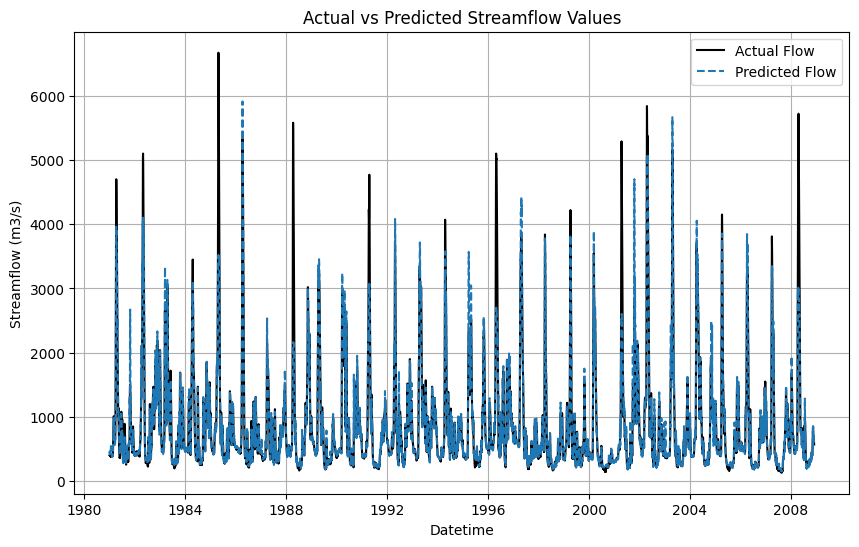

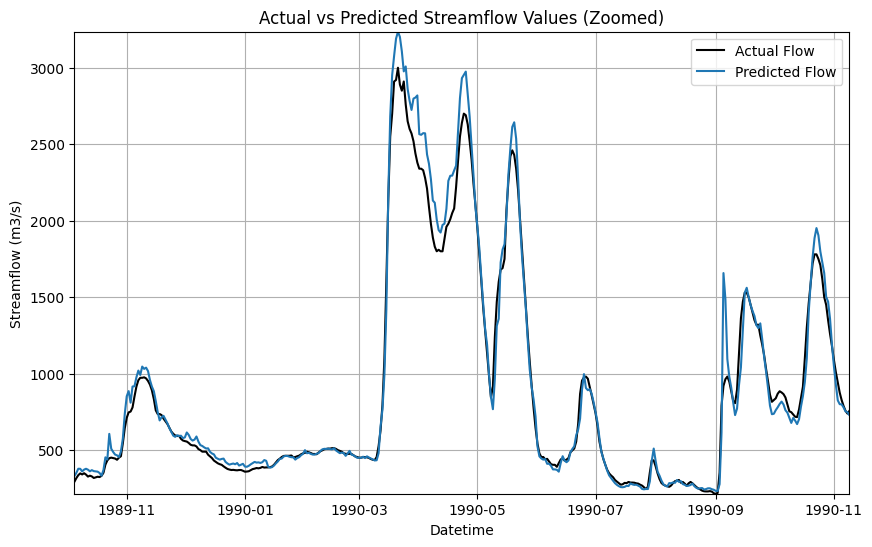

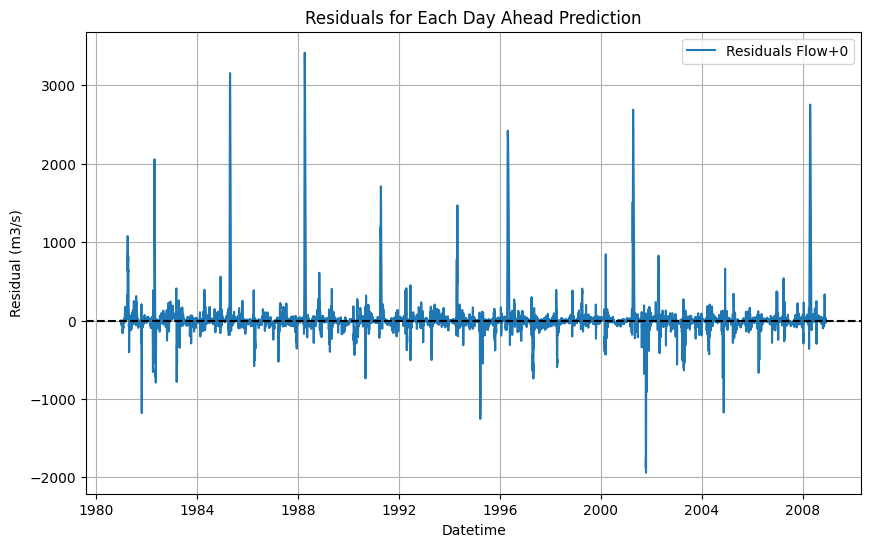

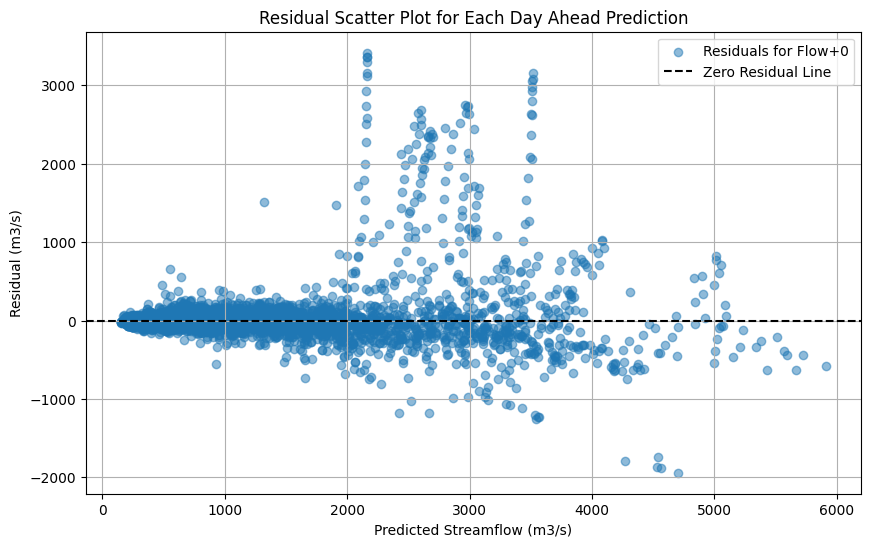

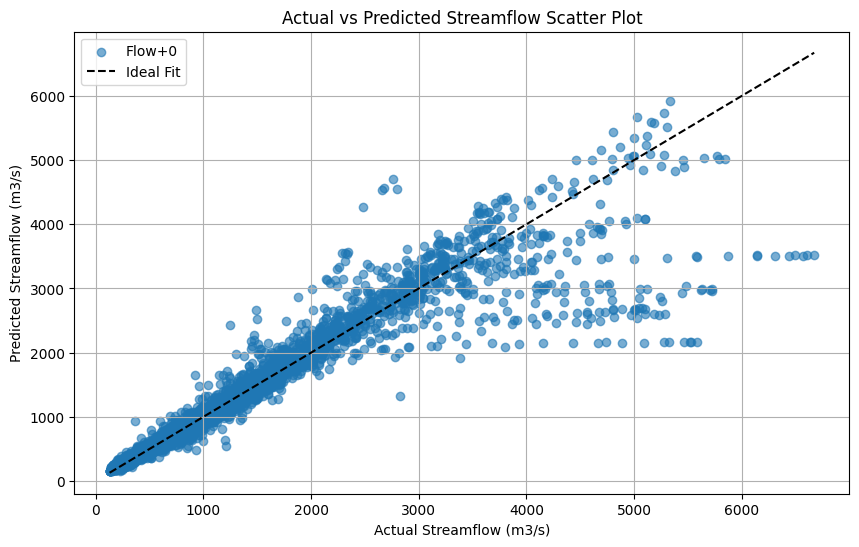

lstm.weight_ih_l0: torch.Size([256, 34])
tensor([[-0.5619, -0.0433, -0.1027,  ...,  0.3084,  0.2083,  0.3605],
        [ 0.3339,  0.2043,  0.1653,  ..., -0.2331, -0.2421, -0.2423],
        [ 0.5698, -0.4618,  0.3804,  ...,  0.0470, -0.0847, -0.2697],
        ...,
        [ 0.2556, -0.1182, -0.0034,  ...,  0.6276,  0.2533,  0.6684],
        [ 0.3048, -0.2606, -0.3446,  ..., -0.6797, -0.3146, -0.6103],
        [ 0.9784, -0.4775, -0.3417,  ..., -0.2171,  0.1663, -0.3397]],
       device='cuda:0')
lstm.weight_hh_l0: torch.Size([256, 64])
tensor([[ 0.1068,  0.0489,  0.0506,  ..., -0.0773, -0.0659, -0.0410],
        [ 0.0337,  0.0404,  0.0774,  ...,  0.0749,  0.0239, -0.0888],
        [-0.0335,  0.0774,  0.0352,  ..., -0.0094, -0.0343, -0.0942],
        ...,
        [ 0.0907,  0.0996,  0.1169,  ..., -0.1012, -0.0541,  0.0225],
        [ 0.0747,  0.0734, -0.0366,  ...,  0.0067,  0.0526, -0.1180],
        [-0.0362,  0.0581,  0.0071,  ..., -0.1140, -0.0351,  0.0799]],
       device='cuda:0')
ls

In [7]:
visualization(datetime1, y_pred, y_test, 3200,3600)
print_model_weights_and_biases(model)

In [8]:
df, X, Y = CAMELSrun('13340000', 3, 7, 'Flow+1', False)

c:\Users\abdul\Documents\FloodLearning\functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(f'{flow}', delim_whitespace=True, header=None)
c:\Users\abdul\Documents\FloodLearning\functions.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(f'{meta}', skiprows=3, delim_whitespace=True)


In [9]:
predictions1, datetime2 = backtest(df, model, X, Y, 200, 365, 60, None, device)

y_pred1 = predictions1["prediction"]
y_test1 = predictions1["actual"]

y_pred1 = np.maximum(y_pred1, 0)  # Ensure no negative predictions1
y_pred1 = np.minimum(y_pred1, np.max(y_test1) * 1.1)  # Cap predictions1 at 10% above max value of y_test

Epoch 1/200, Loss: 0.047751897014677525
Epoch 2/200, Loss: 0.03543804845927904
Epoch 3/200, Loss: 0.03111410265167554
Epoch 4/200, Loss: 0.030680011259391904
Epoch 5/200, Loss: 0.024636359186843038
Epoch 6/200, Loss: 0.024481986494114
Epoch 7/200, Loss: 0.021180921816267073
Epoch 8/200, Loss: 0.020690361813952524
Epoch 9/200, Loss: 0.017558130901306868
Epoch 10/200, Loss: 0.01708452096985032
Epoch 11/200, Loss: 0.014229789609089494
Epoch 12/200, Loss: 0.01483544932367901
Epoch 13/200, Loss: 0.013425068910388896
Epoch 14/200, Loss: 0.012820124626159668
Epoch 15/200, Loss: 0.011076676775701344
Epoch 16/200, Loss: 0.009695443562425984
Epoch 17/200, Loss: 0.01026272788294591
Epoch 18/200, Loss: 0.008326615439727902
Epoch 19/200, Loss: 0.008350713624774167
Epoch 20/200, Loss: 0.008562130329664797
Epoch 21/200, Loss: 0.008248686557635665
Epoch 22/200, Loss: 0.008323922054842114
Epoch 23/200, Loss: 0.007354096499814962
Epoch 24/200, Loss: 0.007366505121657004
Epoch 25/200, Loss: 0.00658386478

MAE: 1038.3 m3/s
MSE: 6465346.21 m3/s
RMSE: 2542.7 m3/s
MAPE: 0.13%
Accuracy: 99.869%
R2: 0.9382


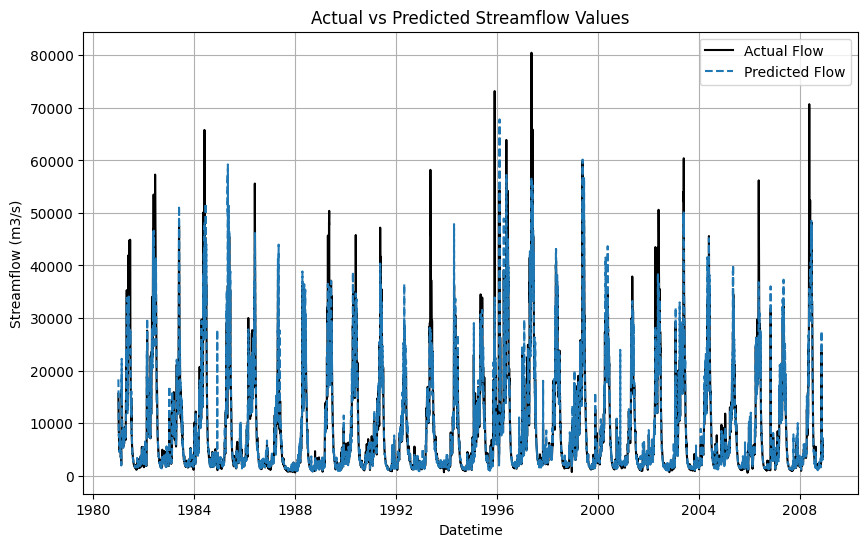

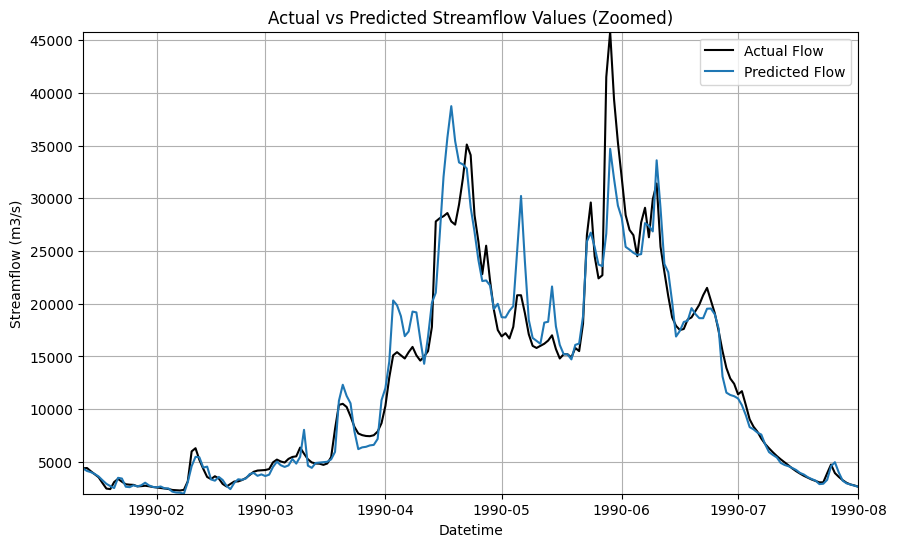

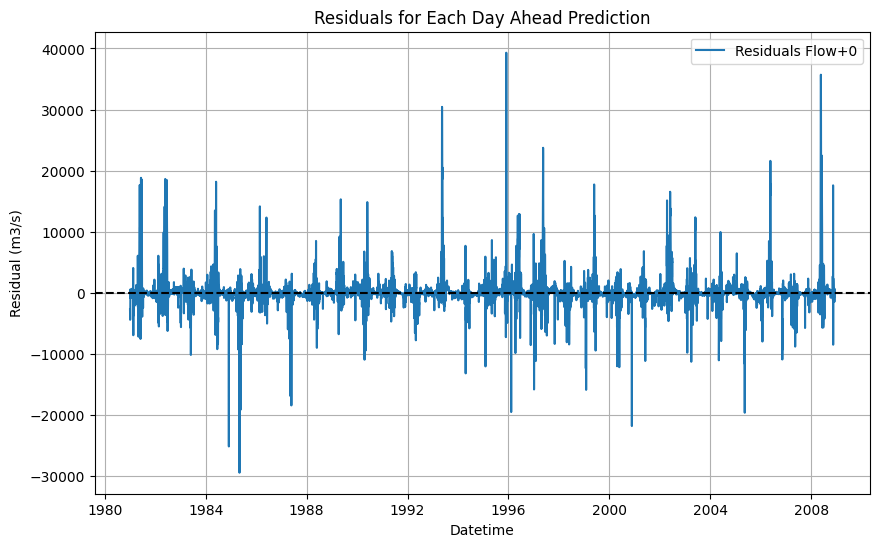

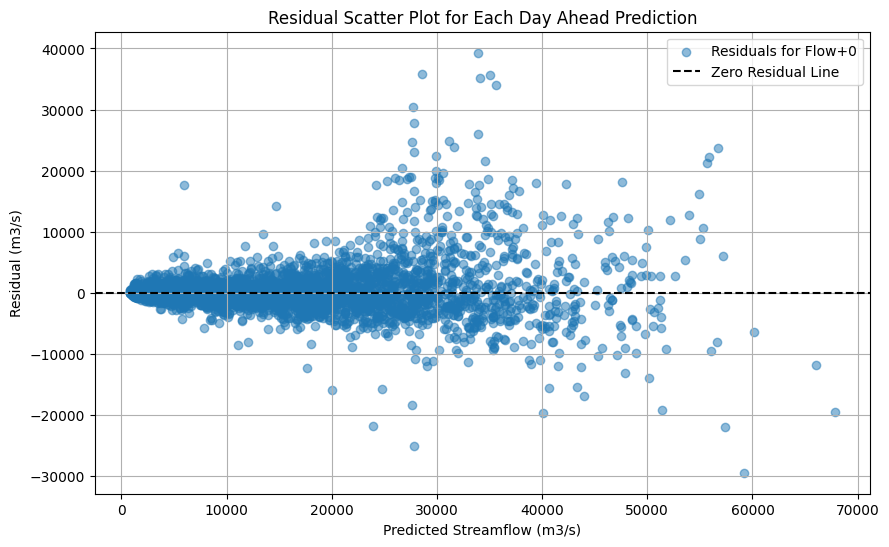

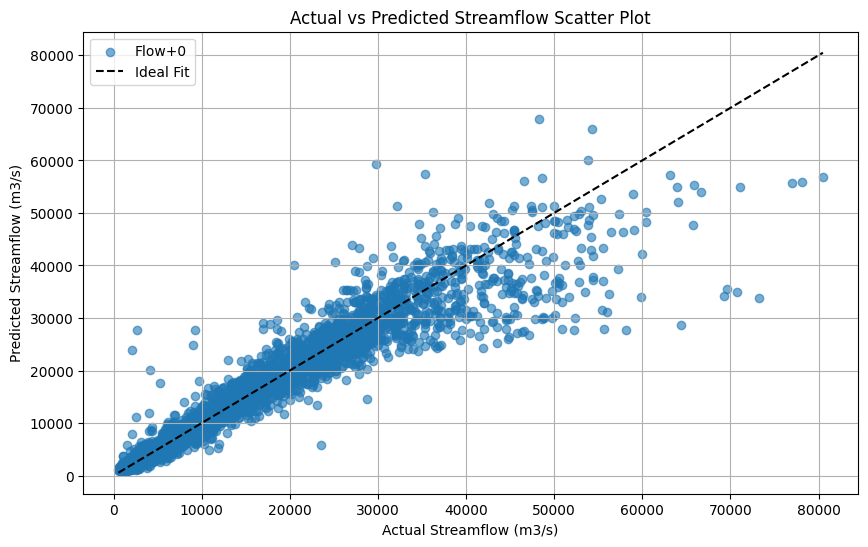

lstm.weight_ih_l0: torch.Size([256, 34])
tensor([[-0.5350,  0.1282, -0.4544,  ...,  0.1925,  0.3559,  0.3566],
        [ 0.0968,  0.9182, -0.0920,  ..., -0.2232, -0.6890, -0.5346],
        [ 0.5320, -0.8235, -0.1977,  ..., -0.3003, -0.1564, -0.3885],
        ...,
        [ 0.3097,  0.7588,  0.3364,  ...,  0.0126, -0.1385,  0.0871],
        [ 0.3153, -0.8269,  0.1390,  ..., -0.8343, -1.0836, -1.1902],
        [ 2.5120, -0.1642, -0.0359,  ..., -0.3213, -0.1689, -0.1950]],
       device='cuda:0')
lstm.weight_hh_l0: torch.Size([256, 64])
tensor([[ 0.1068,  0.0489,  0.0506,  ..., -0.0773, -0.0659, -0.0410],
        [ 0.0337,  0.0404,  0.0774,  ...,  0.0749,  0.0239, -0.0888],
        [-0.0335,  0.0774,  0.0352,  ..., -0.0094, -0.0343, -0.0942],
        ...,
        [ 0.0907,  0.0996,  0.1169,  ..., -0.1012, -0.0541,  0.0225],
        [ 0.0747,  0.0734, -0.0366,  ...,  0.0067,  0.0526, -0.1180],
        [-0.0362,  0.0581,  0.0071,  ..., -0.1140, -0.0351,  0.0799]],
       device='cuda:0')
ls

In [10]:
visualization(datetime2, y_pred1, y_test1, 3300, 3500)
print_model_weights_and_biases(model)

In [11]:
df, X, Y = CAMELSrun('05131500', 3, 7, 'Flow+2', False)

predictions2, datetime3 = backtest(df, model, X, Y, 200, 365, 60, None, device)

y_pred2 = predictions2["prediction"]
y_test2 = predictions2["actual"]

y_pred2 = np.maximum(y_pred2, 0)  # Ensure no negative predictions2
y_pred2 = np.minimum(y_pred2, np.max(y_test2) * 1.1)  # Cap predictions2 at 10% above max value of y_test


c:\Users\abdul\Documents\FloodLearning\functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(f'{flow}', delim_whitespace=True, header=None)
c:\Users\abdul\Documents\FloodLearning\functions.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(f'{meta}', skiprows=3, delim_whitespace=True)


Epoch 1/200, Loss: 0.14227667668213448
Epoch 2/200, Loss: 0.12124572647735476
Epoch 3/200, Loss: 0.10166852812593181
Epoch 4/200, Loss: 0.0878487507191797
Epoch 5/200, Loss: 0.07743058182920019
Epoch 6/200, Loss: 0.07226954656653106
Epoch 7/200, Loss: 0.06624891298512618
Epoch 8/200, Loss: 0.04815904089870552
Epoch 9/200, Loss: 0.058883802965283394
Epoch 10/200, Loss: 0.04681196389719844
Epoch 11/200, Loss: 0.03481488962036868
Epoch 12/200, Loss: 0.04021175865394374
Epoch 13/200, Loss: 0.03225835432143261
Epoch 14/200, Loss: 0.026929358136840165
Epoch 15/200, Loss: 0.022797825804445893
Epoch 16/200, Loss: 0.02674431020083527
Epoch 17/200, Loss: 0.023825319910732407
Epoch 18/200, Loss: 0.018196878139860928
Epoch 19/200, Loss: 0.015205469292898973
Epoch 20/200, Loss: 0.01708054185534517
Epoch 21/200, Loss: 0.016158200800418854
Epoch 22/200, Loss: 0.016906666666424524
Epoch 23/200, Loss: 0.014912780335483452
Epoch 24/200, Loss: 0.013223453153235218
Epoch 25/200, Loss: 0.013139741495251656

MAE: 269.48 m3/s
MSE: 587535.06 m3/s
RMSE: 766.51 m3/s
MAPE: 0.32%
Accuracy: 99.678%
R2: 0.7777


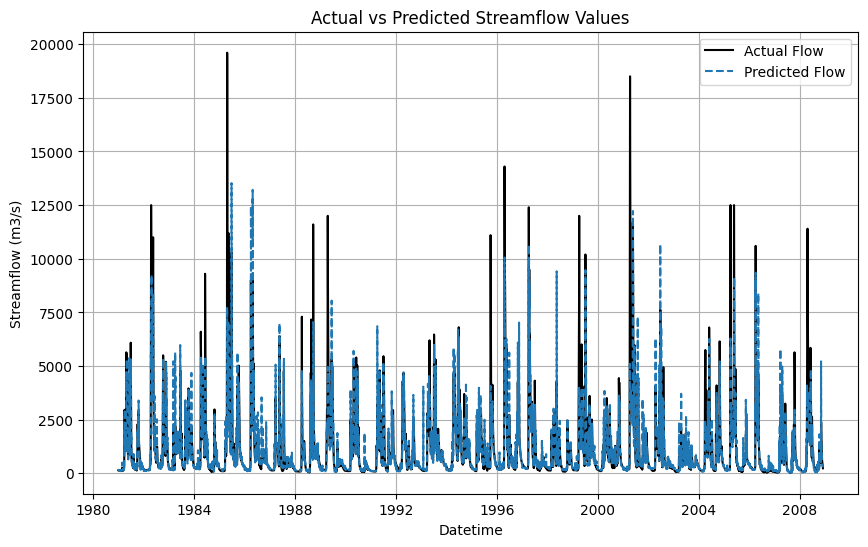

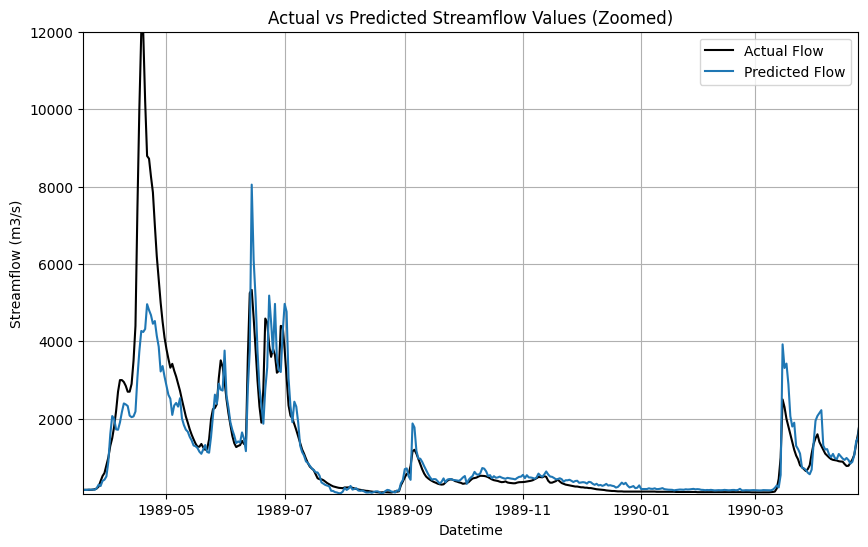

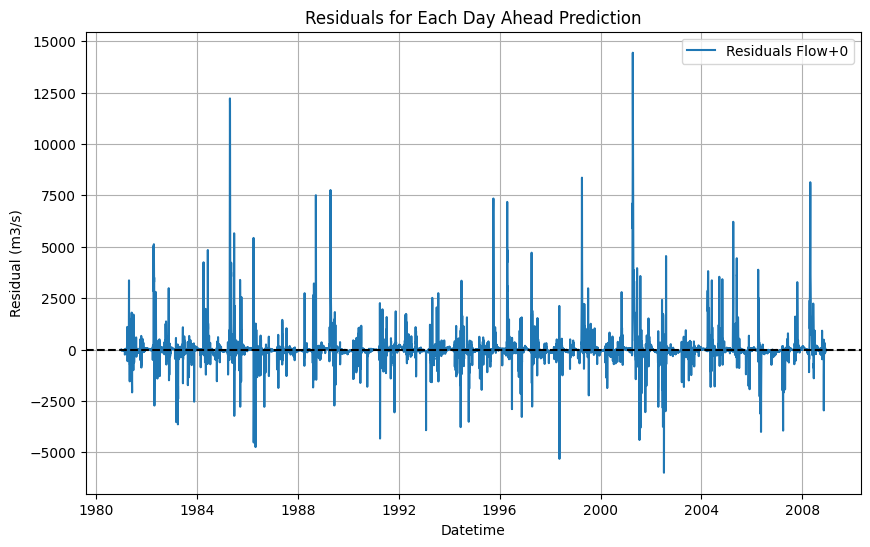

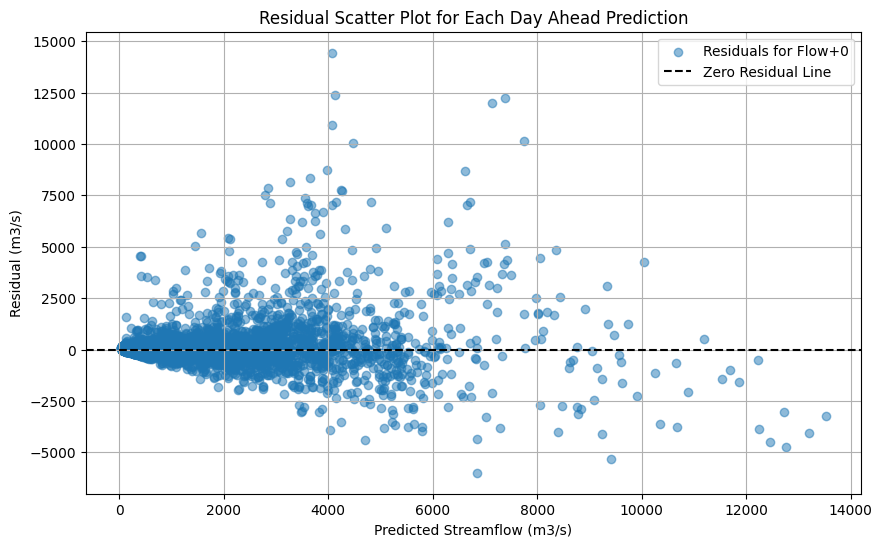

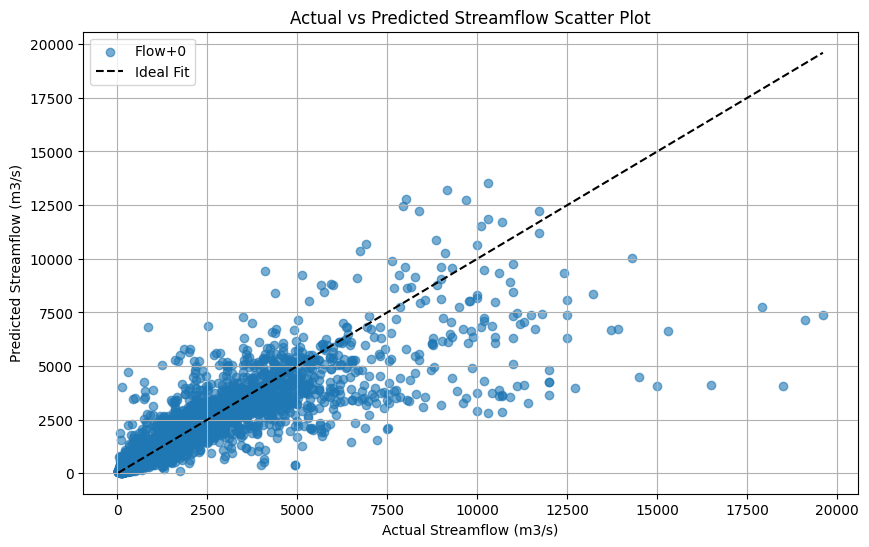

lstm.weight_ih_l0: torch.Size([256, 34])
tensor([[-0.6697, -0.0169, -0.3975,  ...,  0.0837,  0.5721,  0.3282],
        [ 0.1726,  1.2513,  0.5397,  ...,  0.2527, -0.0576,  0.1657],
        [-0.0606, -1.2956,  0.2875,  ..., -1.9126, -0.7494, -2.2878],
        ...,
        [ 0.2883,  0.8076,  0.1100,  ...,  0.1657,  0.5531,  0.2765],
        [-0.4509, -0.4528, -0.2544,  ..., -1.3303, -1.3042, -1.7177],
        [ 2.7864, -0.5811,  0.1678,  ..., -0.3951, -0.4625, -0.5863]],
       device='cuda:0')
lstm.weight_hh_l0: torch.Size([256, 64])
tensor([[ 0.1068,  0.0489,  0.0506,  ..., -0.0773, -0.0659, -0.0410],
        [ 0.0337,  0.0404,  0.0774,  ...,  0.0749,  0.0239, -0.0888],
        [-0.0335,  0.0774,  0.0352,  ..., -0.0094, -0.0343, -0.0942],
        ...,
        [ 0.0907,  0.0996,  0.1169,  ..., -0.1012, -0.0541,  0.0225],
        [ 0.0747,  0.0734, -0.0366,  ...,  0.0067,  0.0526, -0.1180],
        [-0.0362,  0.0581,  0.0071,  ..., -0.1140, -0.0351,  0.0799]],
       device='cuda:0')
ls

In [12]:
visualization(datetime3, y_pred2, y_test2, 3000, 3400)
print_model_weights_and_biases(model)

In [14]:
import datetime as dt

current_time = dt.datetime.now().strftime("%Y%m%d-%H%M%S")
print(current_time)


torch.save(model.state_dict(), f"./models/LSTM_200_365_60_{current_time}.pth")

20250324-175927
